# Fine-tuning T5-small for Question Generation

## What this notebook does
Takes the **base T5-small model** (no task-specific training) and fine-tunes it
on the **SQuAD v1.1 dataset** to teach it to generate questions from a passage
given a highlighted answer span.

## Why SQuAD?
SQuAD (Stanford Question Answering Dataset) has ~87,000 (passage, question, answer)
triples written by human annotators from Wikipedia. It is the standard benchmark
dataset for question generation research.

## Input/Output format (highlight format)
```
Input:  generate question: ISRO was founded in <hl> 1969 <hl> by Vikram Sarabhai.
Output: In what year was ISRO founded?
```

## Before running
**Enable GPU:** Runtime -> Change runtime type -> T4 GPU

## Estimated time
~45 minutes on free Colab T4 GPU (3 epochs, 10,000 training examples)

In [ ]:
# CELL 1 — Install and verify GPU
!pip install transformers datasets sentencepiece torch -q

import torch
print(f'PyTorch  : {torch.__version__}')
print(f'GPU      : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU name : {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU found. Go to Runtime > Change runtime type > T4 GPU')

PyTorch  : 2.10.0+cu128
GPU      : True
GPU name : Tesla T4


In [ ]:
# CELL 2 — Load SQuAD dataset
from datasets import load_dataset

print('Loading SQuAD v1.1...')
squad = load_dataset('squad')
print(f"Train : {len(squad['train']):,} examples")
print(f"Val   : {len(squad['validation']):,} examples")

# Show one example so you understand the structure
ex = squad['train'][5]
print(f"\nSample:")
print(f"  Context  : {ex['context'][:120]}...")
print(f"  Question : {ex['question']}")
print(f"  Answer   : {ex['answers']['text'][0]}")

Loading SQuAD v1.1...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

Train : 87,599 examples
Val   : 10,570 examples

Sample:
  Context  : As at most other universities, Notre Dame's students run a number of news media outlets. The nine student-run outlets in...
  Question : When did the Scholastic Magazine of Notre dame begin publishing?
  Answer   : September 1876


In [ ]:
# CELL 3 — Format examples for T5
# T5 needs text -> text format.
# We highlight the answer inside the context using <hl> tags.

def format_example(example):
    context  = example['context']
    question = example['question']
    answer   = example['answers']['text'][0]
    start    = example['answers']['answer_start'][0]
    end      = start + len(answer)

    # Wrap answer in highlight tags
    highlighted = context[:start] + f' <hl> {answer} <hl> ' + context[end:]
    input_text  = f'generate question: {highlighted.strip()}'
    target_text = question.strip()

    return {'input_text': input_text, 'target_text': target_text}

print('Formatting...')
train_data = squad['train'].map(format_example, remove_columns=squad['train'].column_names)
val_data   = squad['validation'].map(format_example, remove_columns=squad['validation'].column_names)

print('Sample formatted:')
print(f"  Input  : {train_data[0]['input_text'][:130]}...")
print(f"  Target : {train_data[0]['target_text']}")

Formatting...


Map:   0%|          | 0/87599 [00:00<?, ? examples/s]

Map:   0%|          | 0/10570 [00:00<?, ? examples/s]

Sample formatted:
  Input  : generate question: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of ...
  Target : To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?


In [ ]:
# CELL 4 — Load BASE T5-small
# We load 't5-small' — the base model with NO fine-tuning.
# This is what we will train ourselves from scratch on SQuAD.
from transformers import T5ForConditionalGeneration, T5Tokenizer

MODEL_NAME = 't5-small'  # BASE — no task-specific training yet
print(f'Loading base model: {MODEL_NAME}')

tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
model     = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)

print(f'Parameters: {model.num_parameters():,}')
print('Model loaded.')

Loading base model: t5-small


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Parameters: 60,506,624
Model loaded.


In [ ]:
# CELL 5 — Tokenize
# Convert text strings to token IDs that the model understands.

MAX_INPUT  = 512
MAX_TARGET = 64
TRAIN_SIZE = 10000   # use full size later
VAL_SIZE   = 1000

def tokenize(batch):
    # Tokenize input (encoder)
    inputs = tokenizer(
        batch['input_text'],
        max_length=MAX_INPUT,
        truncation=True,
        padding='max_length'
    )

    # Tokenize target (decoder)
    labels = tokenizer(
        text_target=batch['target_text'],
        max_length=MAX_TARGET,
        truncation=True,
        padding='max_length'
    )

    # Replace padding token id with -100 (ignore in loss)
    inputs['labels'] = [
        [(t if t != tokenizer.pad_token_id else -100) for t in lab]
        for lab in labels['input_ids']
    ]

    return inputs


print('Tokenizing (takes ~2 mins)...')

tok_train = train_data.select(range(TRAIN_SIZE)).map(
    tokenize,
    batched=True,
    batch_size=256,
    remove_columns=['input_text', 'target_text']
)

tok_val = val_data.select(range(VAL_SIZE)).map(
    tokenize,
    batched=True,
    batch_size=256,
    remove_columns=['input_text', 'target_text']
)

# Set format for PyTorch
tok_train.set_format(type='torch')
tok_val.set_format(type='torch')

print('Done.')

Tokenizing (takes ~2 mins)...


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Done.


In [ ]:
# CELL 6 — Fine-tune using Seq2SeqTrainer
# Fixed for transformers v4.46+ (processing_class instead of tokenizer)

from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)

args = Seq2SeqTrainingArguments(
    output_dir                  = './t5-qg-finetuned',
    num_train_epochs            = 3,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 8,
    learning_rate               = 3e-4,
    weight_decay                = 0.01,
    warmup_steps                = 200,
    eval_strategy               = 'steps',
    eval_steps                  = 500,
    save_steps                  = 500,
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    predict_with_generate       = True,
    generation_max_length       = 64,
    logging_steps               = 100,
    fp16                        = True,
    report_to                   = 'none',
)

trainer = Seq2SeqTrainer(
    model            = model,
    args             = args,
    train_dataset    = tok_train,
    eval_dataset     = tok_val,
    processing_class = tokenizer,
    data_collator    = data_collator,
)

print(f'Training {TRAIN_SIZE} examples for {args.num_train_epochs} epochs...')
print('This will take ~45 minutes on T4 GPU. Do not close the tab.')
print()

result = trainer.train()

print()
print(f'Training complete!')
print(f'Final training loss : {result.training_loss:.4f}')
print(f'Total steps         : {result.global_step}')

Training 10000 examples for 3 epochs...
This will take ~45 minutes on T4 GPU. Do not close the tab.



/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


Step,Training Loss,Validation Loss
500,1.983035,1.884406
1000,1.845085,1.829677
1500,1.658159,1.831580
2000,1.665812,1.812826
2500,1.597580,1.791322
3000,1.415571,1.807078
3500,1.388954,1.799262


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].



Training complete!
Final training loss : 1.7124
Total steps         : 3750


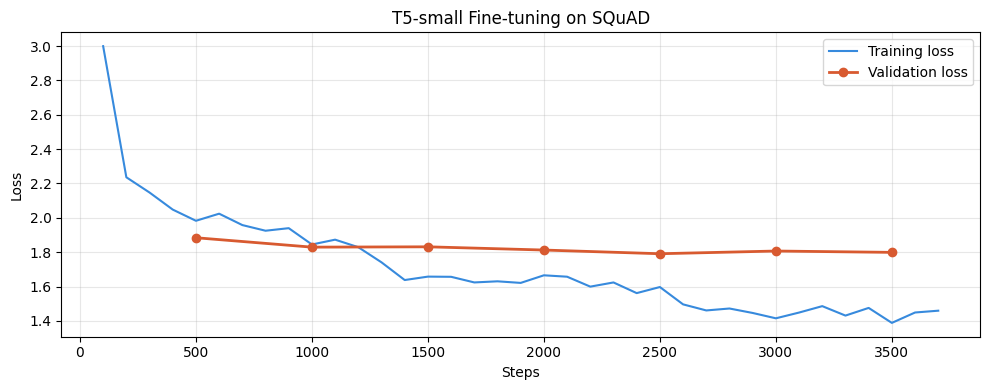

Saved: loss_curve.png


In [ ]:
# CELL 7 — Plot loss curve (show your professor this!)
import matplotlib.pyplot as plt

logs   = trainer.state.log_history
t_loss = [(x['step'], x['loss'])      for x in logs if 'loss' in x and 'eval_loss' not in x]
e_loss = [(x['step'], x['eval_loss']) for x in logs if 'eval_loss' in x]

ts, tl = zip(*t_loss)
es, el = zip(*e_loss)

plt.figure(figsize=(10, 4))
plt.plot(ts, tl, label='Training loss',   color='#378ADD')
plt.plot(es, el, label='Validation loss', color='#D85A30', marker='o', linewidth=2)
plt.xlabel('Steps'); plt.ylabel('Loss')
plt.title('T5-small Fine-tuning on SQuAD')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()
print('Saved: loss_curve.png')

In [ ]:
# CELL 7 — Compare fine-tuned vs baseline (no pipeline)

import torch

device = 0 if torch.cuda.is_available() else -1

# Load baseline model directly
from transformers import T5ForConditionalGeneration, T5Tokenizer

print("Loading baseline model...")
bl_tokenizer = T5Tokenizer.from_pretrained('valhalla/t5-small-qg-hl')
bl_model     = T5ForConditionalGeneration.from_pretrained('valhalla/t5-small-qg-hl')
if torch.cuda.is_available():
    bl_model = bl_model.cuda()

# Our fine-tuned model is already in memory as 'model' and 'tokenizer'
if torch.cuda.is_available():
    model.cuda()

def generate_question(mdl, tok, input_text):
    """Generate a question using direct model call instead of pipeline."""
    inputs = tok(
        input_text,
        return_tensors  = 'pt',
        max_length      = 512,
        truncation      = True,
        padding         = True,
    )
    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}

    with torch.no_grad():
        outputs = mdl.generate(
            inputs['input_ids'],
            max_new_tokens  = 64,
            num_beams       = 4,
            early_stopping  = True,
        )
    return tok.decode(outputs[0], skip_special_tokens=True)


# Test on 5 examples
tests = [
    'generate question: ISRO was founded in 1969 by <hl> Vikram Sarabhai <hl>.',
    'generate question: Marie Curie won the Nobel Prize in <hl> 1903 <hl>.',
    'generate question: The D-Day invasion took place on <hl> June 6, 1944 <hl> in Normandy.',
    'generate question: Albert Einstein was born in <hl> Ulm, Germany <hl> in 1879.',
    'generate question: The <hl> Taj Mahal <hl> was built by Shah Jahan in 1632.',
]

print('\nCOMPARISON — Baseline vs Our Fine-tuned Model')
print('=' * 70)
for i, inp in enumerate(tests, 1):
    our_q = generate_question(model,    tokenizer,    inp)
    bl_q  = generate_question(bl_model, bl_tokenizer, inp)
    print(f'\nTest {i}: ...{inp[30:75]}...')
    print(f'  Baseline : {bl_q}')
    print(f'  Ours     : {our_q}')
print('=' * 70)

Loading baseline model...


tokenizer_config.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/31.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/242M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



COMPARISON — Baseline vs Our Fine-tuned Model

Test 1: ...unded in 1969 by <hl> Vikram Sarabhai <hl>....
  Baseline : Who founded ISRO?
  Ours     : Who founded ISRO?

Test 2: ... won the Nobel Prize in <hl> 1903 <hl>....
  Baseline : When did Marie Curie win the Nobel Prize?
  Ours     : What year did Marie Curie win the Nobel prize?

Test 3: ...nvasion took place on <hl> June 6, 1944 <hl> ...
  Baseline : When did the D-Day invasion take place?
  Ours     : When did the D-Day invasion occur?

Test 4: ...tein was born in <hl> Ulm, Germany <hl> in 18...
  Baseline : Where was Albert Einstein born?
  Ours     : Where was Albert Einstein born?

Test 5: ...j Mahal <hl> was built by Shah Jahan in 1632....
  Baseline : What was built by Shah Jahan?
  Ours     : What was built by Shah Jahan in 1632?


In [ ]:
# CELL 9 — Save to Google Drive
# IMPORTANT: Colab resets when session ends. Save now!
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH = '/content/drive/MyDrive/t5-qg-finetuned'
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f'Model saved to: {SAVE_PATH}')
print()
print('NEXT STEPS:')
print('1. Download the t5-qg-finetuned folder from Google Drive')
print('2. Place it under  mcq_generator/models/t5-qg-finetuned/')
print('3. In config.py set:  QG_MODEL_NAME = "models/t5-qg-finetuned"')
print('4. Run:  streamlit run app/main.py')

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/t5-qg-finetuned

NEXT STEPS:
1. Download the t5-qg-finetuned folder from Google Drive
2. Place it under  mcq_generator/models/t5-qg-finetuned/
3. In config.py set:  QG_MODEL_NAME = "models/t5-qg-finetuned"
4. Run:  streamlit run app/main.py


##Performance Matrix

In [ ]:
!pip install rouge-score bert-score nltk -q
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
print("done")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.3 MB/s eta 0:00:00
done


In [ ]:
from datasets import load_dataset
import torch

squad_val    = load_dataset('squad', split='validation')
test_data    = squad_val.select(range(30))

references      = []
our_predictions = []
bl_predictions  = []

for i, ex in enumerate(test_data):
    context = ex['context']
    answer  = ex['answers']['text'][0]
    start   = ex['answers']['answer_start'][0]
    end     = start + len(answer)

    inp = f"generate question: {context[:start]} <hl> {answer} <hl> {context[end:]}".strip()

    our_q = tokenizer.decode(
        model.generate(
            tokenizer(inp, return_tensors='pt', max_length=512, truncation=True).input_ids.cuda(),
            max_new_tokens=64, num_beams=4
        )[0], skip_special_tokens=True)

    bl_q = bl_tokenizer.decode(
        bl_model.generate(
            bl_tokenizer(inp, return_tensors='pt', max_length=512, truncation=True).input_ids.cuda(),
            max_new_tokens=64, num_beams=4
        )[0], skip_special_tokens=True)

    references.append(ex['question'])
    our_predictions.append(our_q)
    bl_predictions.append(bl_q)
    if (i+1) % 10 == 0:
        print(f"{i+1}/30 done")

print("generation complete")

10/30 done
20/30 done
30/30 done
generation complete


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Metric          Our Model     Baseline
--------------------------------------
BLEU-2             0.1841       0.1556 ← better
ROUGE-L            0.3260       0.2757 ← better
BERTScore          0.9138       0.9067 ← better


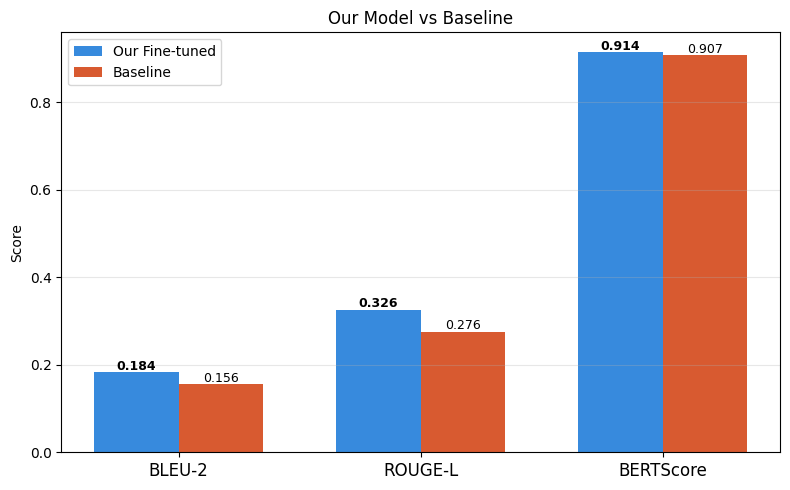

saved: metrics.png


In [ ]:
# compute and plot metrics
import numpy as np
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer as rs
from bert_score import score as bscore

sm = SmoothingFunction().method1

def bleu(r, h):
    return sentence_bleu([r.lower().split()], h.lower().split(), weights=(0.5,0.5), smoothing_function=sm)

def rouge(r, h):
    return rs.RougeScorer(['rougeL'], use_stemmer=True).score(r, h)['rougeL'].fmeasure

our_b, our_r, bl_b, bl_r = [], [], [], []

for r, o, b in zip(references, our_predictions, bl_predictions):
    our_b.append(bleu(r, o));  bl_b.append(bleu(r, b))
    our_r.append(rouge(r, o)); bl_r.append(rouge(r, b))

_, _, our_bert = bscore(our_predictions, references, lang='en', verbose=False)
_, _, bl_bert  = bscore(bl_predictions,  references, lang='en', verbose=False)

# print table
labels   = ['BLEU-2', 'ROUGE-L', 'BERTScore']
our_vals = [np.mean(our_b), np.mean(our_r), our_bert.mean().item()]
bl_vals  = [np.mean(bl_b),  np.mean(bl_r),  bl_bert.mean().item()]

print(f"\n{'Metric':<12} {'Our Model':>12} {'Baseline':>12}")
print("-" * 38)
for l, o, b in zip(labels, our_vals, bl_vals):
    win = " ← better" if o >= b else ""
    print(f"{l:<12} {o:>12.4f} {b:>12.4f}{win}")

# plot
x = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, our_vals, w, label='Our Fine-tuned', color='#378ADD')
ax.bar(x + w/2, bl_vals,  w, label='Baseline',       color='#D85A30')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Score'); ax.set_title('Our Model vs Baseline')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for i, (o, b) in enumerate(zip(our_vals, bl_vals)):
    ax.text(i - w/2, o + 0.005, f'{o:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i + w/2, b + 0.005, f'{b:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('metrics.png', dpi=150)
plt.show()
print("saved: metrics.png")